# UNEMPLOYMENT ANALYSIS IN INDIA (2019-2020)

## INTRODUCTION 

This project explores unemployment trends across different Indian states, time periods, and demographic categories using an unemployment dataset. The dataset contains information on estimated unemployment rates, estimated employment, and labour participation rates across various states and months.
The aim of this analysis is to understand how unemployment varies by state , rural and urban areas, and over time, particularly comparing the impact between 2019 and 2020.
To achieve this, the dataset is first cleaned by handling missing values and removing irrelevant or incomplete records. After preprocessing, exploratory data analysis (EDA) is performed using statistical summaries and visualizations such as bar charts, line graphs, scatter plots, and heatmaps to identify patterns and relationships within the data.
The analysis aims to provide insights into regional disparities, temporal trends, and possible impacts of economic disruptions on unemployment rates.

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Environment Ready")

Environment Ready


## Load Dataset

In [2]:
import pandas as pd

df1 = pd.read_csv("Unemployment in India.csv")
df2 = pd.read_csv("Unemployment_Rate_upto_11_2020.csv")

## Data Cleaning and Preprocessing
Before starting the analysis, we inspect the data set for any missing values, data quality, incorrect data format and for incorrect data types. Data Cleaning was performed to ensure accurate analysis and visualization.  

### Dataset Overview

In [3]:
df1.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [4]:
df2.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74


In [5]:
df1.info()
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 9 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                  

### Missing values analysis

In [6]:
df1.isnull().sum()

Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64

In [7]:
df1[df1.isnull().all(axis=1)]

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
359,NaN,NaN,NaN,NaN,NaN,NaN,NaN
360,NaN,NaN,NaN,NaN,NaN,NaN,NaN
361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
362,NaN,NaN,NaN,NaN,NaN,NaN,NaN
363,NaN,NaN,NaN,NaN,NaN,NaN,NaN
364,NaN,NaN,NaN,NaN,NaN,NaN,NaN
365,NaN,NaN,NaN,NaN,NaN,NaN,NaN
366,NaN,NaN,NaN,NaN,NaN,NaN,NaN
367,NaN,NaN,NaN,NaN,NaN,NaN,NaN
368,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
df1.shape

(768, 7)

### Handling Missing Values 

The missing value analysis revealed 28 rows where all columns contained missing values. Since these rows did not contain any useful information, they were removed from the dataset instead of being imputed.

In [9]:
df1 = df1.dropna(how='all')

In [10]:
df1[df1.isnull().all(axis=1)]

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area


In [11]:
df1.shape

(740, 7)

In [12]:
df1.isnull().sum()

Region                                      0
 Date                                       0
 Frequency                                  0
 Estimated Unemployment Rate (%)            0
 Estimated Employed                         0
 Estimated Labour Participation Rate (%)    0
Area                                        0
dtype: int64

## Exploratory Data Analysis

### AVERAGE UNEMPLOYMENT RATE BY REGION 

In [32]:
df1.groupby("Region")["Estimated Unemployment Rate (%)"].mean().sort_values(ascending=False)

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Punjab              12.031071
Puducherry          10.215000
Kerala              10.123929
Tamil Nadu           9.284286
Goa                  9.274167
Chhattisgarh         9.240357
West Bengal          8.124643
Telangana            7.737857
Maharashtra          7.557500
Andhra Pradesh       7.477143
Madhya Pradesh       7.406429
Sikkim               7.249412
Karnataka            6.676071
Gujarat              6.663929
Uttarakhand          6.582963
Assam                6.428077
Odisha               5.657857
Meghalaya            4.798889
Name: Estimated Unemployment Rate (%), dtype: float64

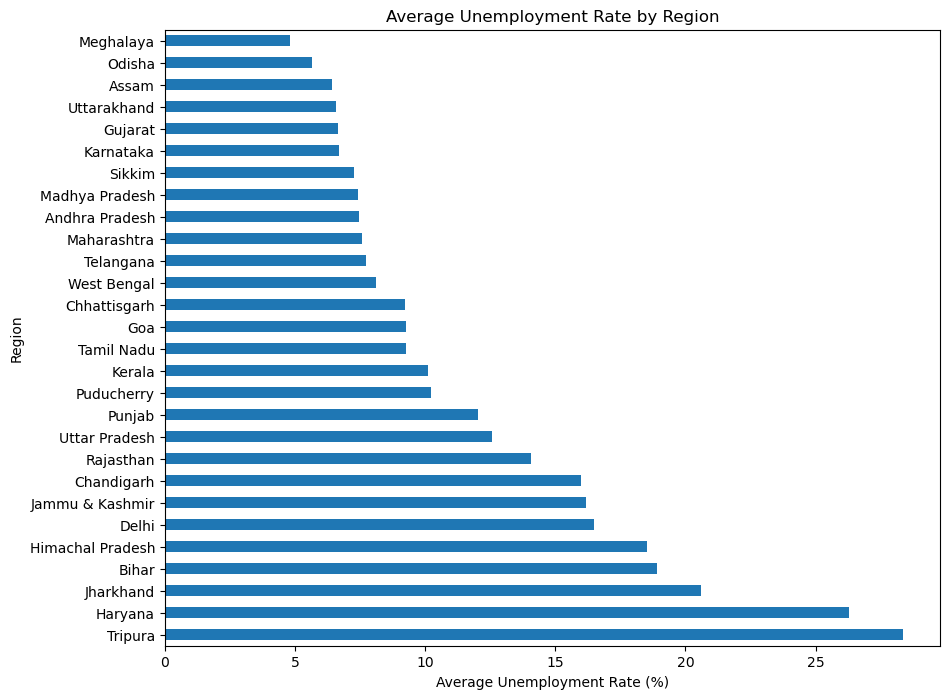

In [69]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

region_avg.plot(kind="barh")

plt.title("Average Unemployment Rate by Region")
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("Region")

plt.show()

### Interpretation 
The above graph shows that Tripura has the higest unemployment rate on average, with Haryana coming in second. Mengalaya recorded the lowest average unemployment rate.
The results indicate a substantial differences across the above states in India.

In [33]:
for col in df1.columns:
    print(repr(col))

'Region'
'Date'
'Frequency'
'Estimated Unemployment Rate (%)'
'Estimated Employed'
'Estimated Labour Participation Rate (%)'
'Area'
'Year'
'Month'


## Feature Analysis and Engineering

New Year and Month columns were created from the Date column to simplify yearly and monthly trend analysis.

In [ ]:
df1["Date"] = pd.to_datetime(df1["Date"])


In [23]:
print(df1.columns.tolist())

['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Area']


In [24]:
df1["Date"] = pd.to_datetime(df1["Date"], dayfirst=True)

In [25]:
df1["Year"] = df1["Date"].dt.year
df1["Month"] = df1["Date"].dt.month_name()

In [26]:
df1[["Date", "Year", "Month"]].head()

,Date,Year,Month
0,2019-05-31,2019,May
1,2019-06-30,2019,June
2,2019-07-31,2019,July
3,2019-08-31,2019,August
4,2019-09-30,2019,September


### ANALYSIS OF AVERAGE UNEMPLOYMENT RATE BY MONTH

In [27]:
monthly_unemployment = df1.groupby("Month")["Estimated Unemployment Rate (%)"].mean().sort_values(ascending=False)

monthly_unemployment

Month
April        23.641569
May          16.646190
March        10.700577
June         10.553462
February      9.964717
January       9.950755
October       9.900909
November      9.868364
August        9.637925
December      9.497358
September     9.051731
July          9.033889
Name: Estimated Unemployment Rate (%), dtype: float64

The data shows a highest unemployment rate in April and lowest in July. 
This is consistent with the lock down in India during COVID 19 pandemic. 

### ANALYSIS OF AVERAGE UNEMPLOYMENT RATE BY YEAR

In [28]:
yearly_unemployment = df1.groupby("Year")["Estimated Unemployment Rate (%)"].mean()

yearly_unemployment

Year
2019     9.399047
2020    15.101581
Name: Estimated Unemployment Rate (%), dtype: float64

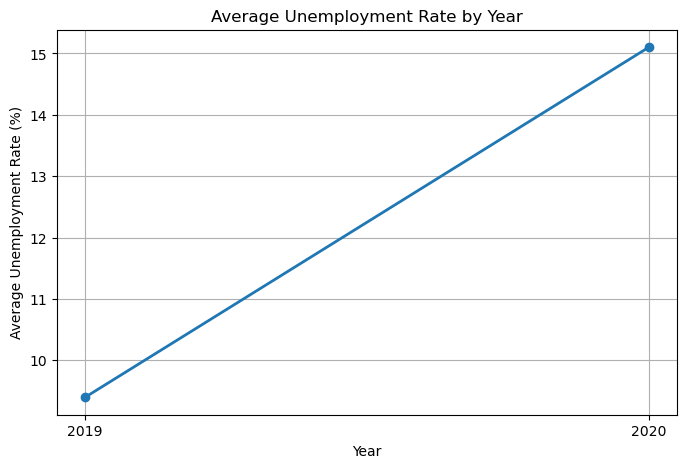

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    yearly_unemployment.index.astype(str),
    yearly_unemployment.values,
    marker='o',
    linewidth=2
)

plt.title("Average Unemployment Rate by Year")
plt.xlabel("Year")
plt.ylabel("Average Unemployment Rate (%)")
plt.grid(True)

plt.show()

### Interpretation
The graph indicates a linear increase in average unemployment rate from the year 2019 at 9.3% to 15.1% in 2020. 
We can conclude that this is consistent with the lockdown due to COVID 19 pandemic.  
Most companies, industries etc closed, workers were layed off, unemployment rates skyrocketed. 

### UNEMPLOYMENT RATE ANALYSIS, URBAN VS RURAL AREAS

In [41]:
area_avg = df1.groupby("Area")["Estimated Unemployment Rate (%)"].mean()

area_avg

Area
Rural    10.324791
Urban    13.166614
Name: Estimated Unemployment Rate (%), dtype: float64

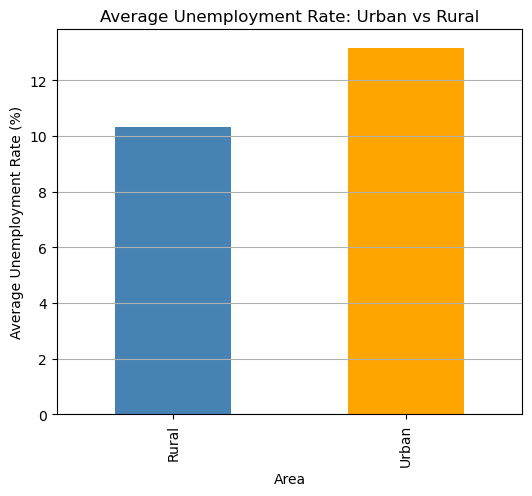

In [62]:
import matplotlib.pyplot as plt

area_avg = df1.groupby("Area")["Estimated Unemployment Rate (%)"].mean()

plt.figure(figsize=(6,5))

area_avg.plot(kind="bar", color=["steelblue", "orange"])

plt.title("Average Unemployment Rate: Urban vs Rural")
plt.xlabel("Area")
plt.ylabel("Average Unemployment Rate (%)")

plt.grid(axis="y")

plt.show()

### Interpretation
Average unemployment rate in rural area (10.3%) is significantly lower than that of urban regions (13.1%). 
Urban areas were affected heavily, they show a higher average unemployment rate  during the lockdown period, this could be because urban economies rely heavily onretail, hospitality, tourism, transportation, offices etc. 
These sectors were severely disrupted by the nationwide lockdown

### LABOUR PARTICIPATION RATE VS UNEMPLOYMENT RATE 

In [45]:
df1["Year"] = df1["Date"].dt.year
df1["Month"] = df1["Date"].dt.month_name()

In [72]:
corr = df1[
    [
        "Estimated Unemployment Rate (%)",
        "Estimated Labour Participation Rate (%)"
    ]
].corr()

corr

,Estimated Unemployment Rate (%),Estimated Labour Participation Rate (%)
Estimated Unemployment Rate (%),1.000000,0.002558
Estimated Labour Participation Rate (%),0.002558,1.000000


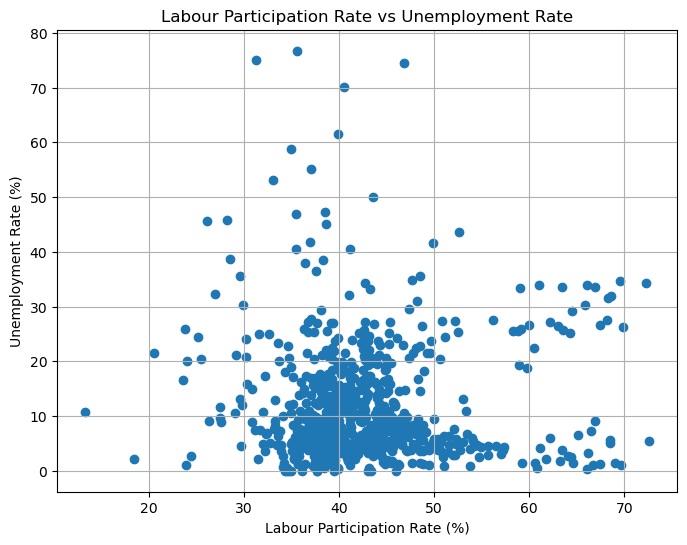

In [63]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    df1["Estimated Labour Participation Rate (%)"],
    df1["Estimated Unemployment Rate (%)"]
)

plt.title("Labour Participation Rate vs Unemployment Rate")
plt.xlabel("Labour Participation Rate (%)")
plt.ylabel("Unemployment Rate (%)")

plt.grid(True)

plt.show()


### Interpretation
The above scatter plot indicates almost no linear corelation within the given dataset. Most observations are concentrated around 35–45% labour participation and below 15% unemployment rate. This is supported by the correlation coefficient, which is close to zero, suggesting almost no linear corelation.

### EMPLOYED VS UNEMPLOYMENT RATE ANALYSIS

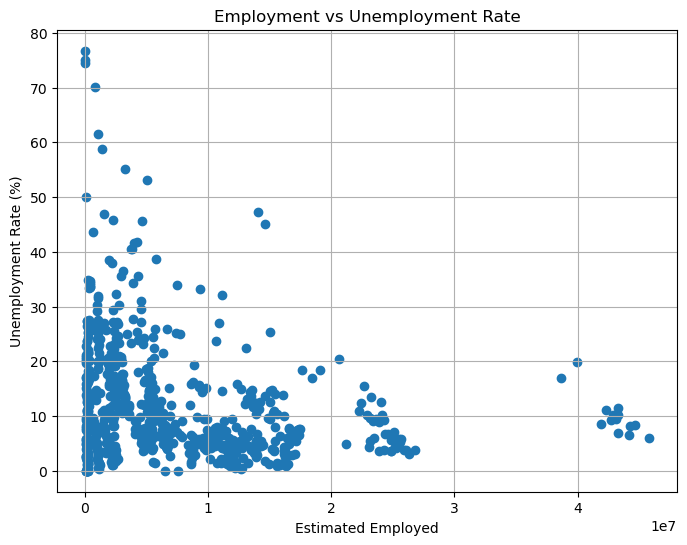

In [64]:
plt.figure(figsize=(8,6))

plt.scatter(
    df1["Estimated Employed"],
    df1["Estimated Unemployment Rate (%)"]
)

plt.title("Employment vs Unemployment Rate")
plt.xlabel("Estimated Employed")
plt.ylabel("Unemployment Rate (%)")

plt.grid(True)

plt.show()

### Interpretation
There is an overall tendency for higher unemployment rate to be associated with lower employment, although the relationship is not perfectly linear because the data combines many states and months. 
We can see this supported by the enagtive corelation (-0.22). 

### CORELATION MATRIX EMPLOYED VS UNEMPLOYMENT RATE VS LABOUR PARTICIPATION 

In [71]:
corr = df1[
    [
        "Estimated Unemployment Rate (%)",
        "Estimated Employed",
        "Estimated Labour Participation Rate (%)"
    ]
].corr()

corr

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
Estimated Unemployment Rate (%),1.000000,-0.222876,0.002558
Estimated Employed,-0.222876,1.000000,0.011300
Estimated Labour Participation Rate (%),0.002558,0.011300,1.000000


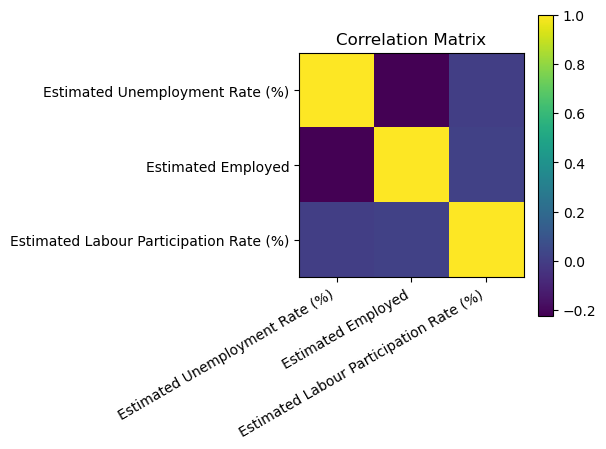

In [68]:
plt.figure(figsize=(6,5))

plt.imshow(corr)

plt.colorbar()

plt.xticks(
    ticks=range(len(corr.columns)),
    labels=corr.columns,
    rotation=30,
    ha="right"
)

plt.yticks(
    ticks=range(len(corr.columns)),
    labels=corr.columns
)

plt.title("Correlation Matrix")

plt.tight_layout()

plt.show()

### Interpretation
Most variables exhibit weak correlations.
This indicates that unemployment cannot be easily explained by a single variable in this dataset. 
Multiple economic factors and social factors such as regional differences, policy measures, industry composition and pandemic effects likely contribute simultaneously.
With the given dataset, the heatmap shows almost no linear corelation between the above variables.

### UNEMPLOYMENT RATE ANALYSIS PER MONTH. 2019 vs 2020

Initially we perform date conversion and reordering of the months
The Date column was converted to datetime format to allow extraction of the year and month for time-series analysis.

In [48]:
month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

df1["Month"] = pd.Categorical(df1["Month"],
                              categories=month_order,
                              ordered=True)

In [51]:
unemployment = df1.pivot_table(
    values="Estimated Unemployment Rate (%)",
    index="Month",
    columns="Year",
    aggfunc="mean",
    observed=False
)

<Figure size 1200x600 with 0 Axes>

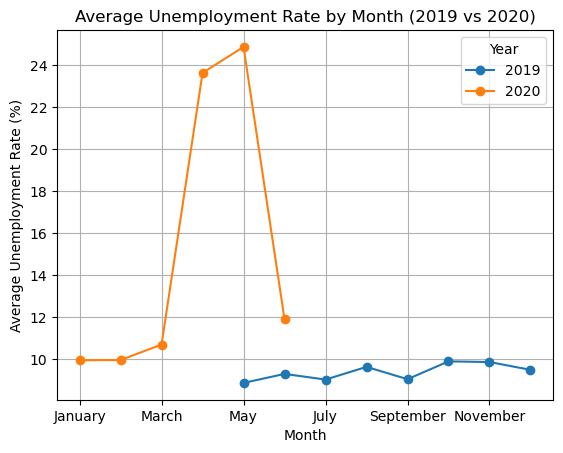

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

unemployment.plot(marker="o")

plt.title("Average Unemployment Rate by Month (2019 vs 2020)")
plt.xlabel("Month")
plt.ylabel("Average Unemployment Rate (%)")

plt.grid(True)

plt.show()

### Interpretation

The graph above shows the different unemployment trends for a given period  from May 2019 to June 2020. Unemployment remained relatively stable throughout 2019, staying below 10% for most of the year. In contrast, unemployment increased sharply beginning around March 2020, peaked in May 2020, and then gradually declined as lockdown restrictions were eased. This pattern is consistent with the economic disruption caused by the COVID-19 lockdown in India.

### MONTHLY DIFFERENCES BETWEEN 2019 AND 2020

In [53]:
monthly_unemployment = df1.pivot_table(
    values="Estimated Unemployment Rate (%)",
    index="Month",
    columns="Year",
    aggfunc="mean"
)

monthly_unemployment

C:\Users\pshim\AppData\Local\Temp\ipykernel_14312\1033064264.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  monthly_unemployment = df1.pivot_table(


Year,2019,2020
Month,,
January,NaN,9.950755
February,NaN,9.964717
March,NaN,10.700577
April,NaN,23.641569
May,8.874259,24.875294
June,9.303333,11.903600
July,9.033889,NaN
August,9.637925,NaN
September,9.051731,NaN


In [56]:
comparison.sort_values(
    by="Difference (2020 - 2019)",
    ascending=False
)

Year,2019,2020,Difference (2020 - 2019)
Month,,,
May,8.874259,24.875294,16.001035
June,9.303333,11.903600,2.600267
January,NaN,9.950755,NaN
February,NaN,9.964717,NaN
March,NaN,10.700577,NaN
April,NaN,23.641569,NaN
July,9.033889,NaN,NaN
August,9.637925,NaN,NaN
September,9.051731,NaN,NaN


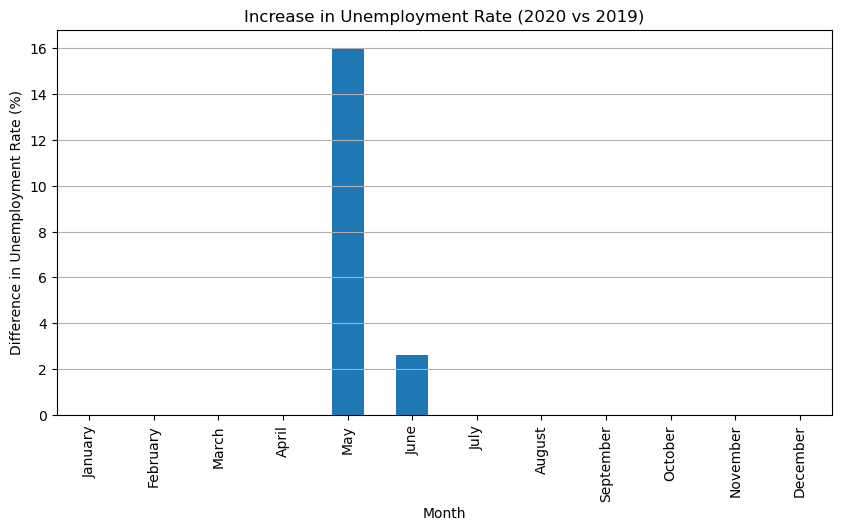

In [57]:
comparison["Difference (2020 - 2019)"].plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Increase in Unemployment Rate (2020 vs 2019)")
plt.ylabel("Difference in Unemployment Rate (%)")
plt.xlabel("Month")
plt.grid(axis="y")

plt.show()

### Interpretation

Many months couldn't be compared because data for one year was unavailable.
Among comparable months,
May showed the largest increase.
This suggests May experienced the greatest labour market disruption
Due to the nationwide lockdown period, intitially starting in March and peaks in May 2020 as lockdoen measures remained in effect (strickest)
We can say most industries and companies suffered huge losses in May as compared to others. 

### HEATMAP ILLUSTRATION OF UNEMPLOYMENT RATE BY STATES AND MONTHS 

In [65]:
heatmap_data = df1.pivot_table(
    values="Estimated Unemployment Rate (%)",
    index="Region",
    columns="Month",
    aggfunc="mean"
)

C:\Users\pshim\AppData\Local\Temp\ipykernel_14312\2449276872.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  heatmap_data = df1.pivot_table(


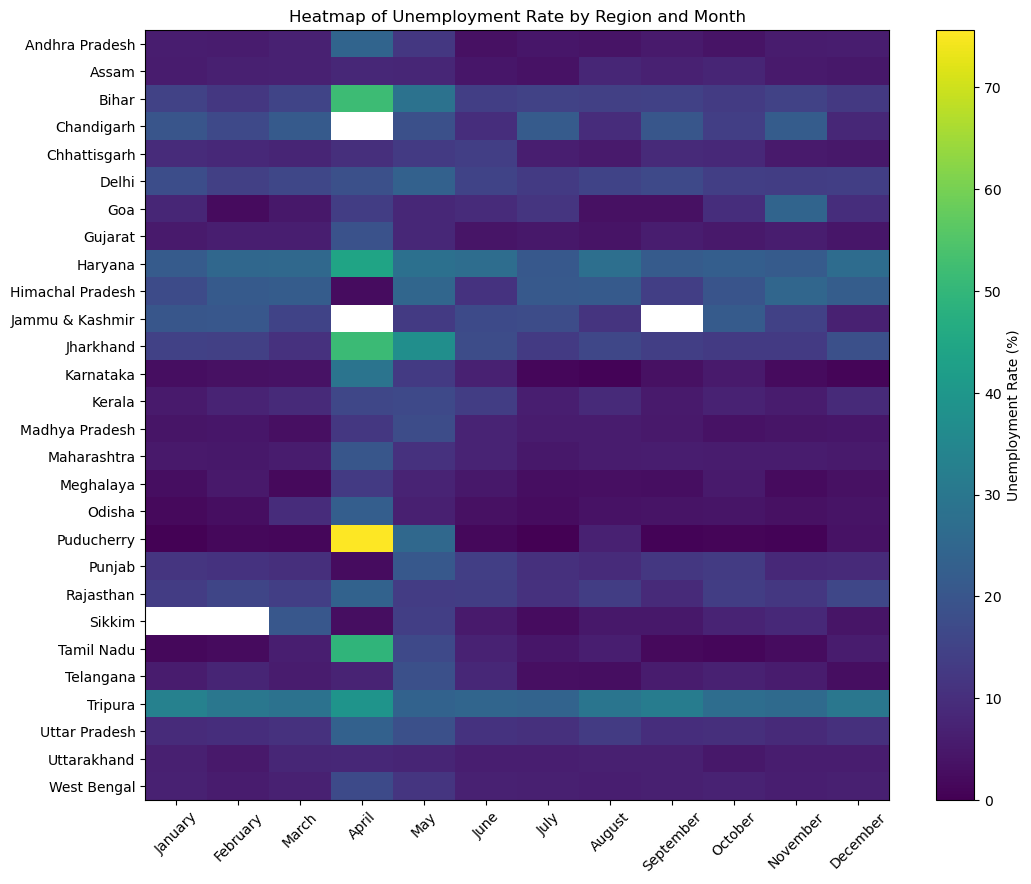

In [66]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))

plt.imshow(heatmap_data, aspect="auto")

plt.colorbar(label="Unemployment Rate (%)")

plt.xticks(
    range(len(heatmap_data.columns)),
    heatmap_data.columns,
    rotation=45
)

plt.yticks(
    range(len(heatmap_data.index)),
    heatmap_data.index
)

plt.title("Heatmap of Unemployment Rate by Region and Month")

plt.show()

### Interpretation

The heatmap illustrates both regional and seasonal variations in unemployment rates across Indian states.
Regions such as Haryana and Tripura consistently recorded relatively high unemployment rates throughout the observed months. Puducherry experienced an unusually high unemployment rate during April and May but much lower rates during the remaining months, suggesting that it may have been disproportionately affected during the strictest phase of the COVID-19 lockdown before recovering. 


## CONCLUSION 

This analysis examined unemployment trends in India between 2019 and 2020 using exploratory data analysis techniques. The findings indicate that average unemployment increased substantially in 2020 compared to 2019, with the sharpest rise occurring between March and May, coinciding with the COVID-19 lockdown period. Urban areas experienced higher unemployment than rural areas, while Tripura and Haryana recorded the highest average unemployment rates and Meghalaya recorded one of the lowest. Correlation analysis showed that labour participation rate had little linear relationship with unemployment, suggesting that unemployment is influenced by multiple factors rather than a single variable. Overall, the analysis highlights the significant economic impact of the COVID-19 pandemic on employment across different regions of India.
